In [76]:
# pip install "chronos-forecasting>=2.0"

In [77]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent  # or use an absolute path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from chronos import Chronos2Pipeline

from experiments.utils import (
    build_model,
    LookBackBuffer,
    prepare_input,
)

from experiments.data_loader import (
    TimeSeriesDataBuilder,
    BatchLoader,
)

from pytagi import Normalizer as normalizer
import pytagi.metric as metric

# Plotting defaults
import matplotlib as mpl

# Update matplotlib parameters in a single dictionary
mpl.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": False,
        "pgf.rcfonts": False,
        "pgf.preamble": r"\usepackage{amsfonts}\usepackage{amssymb}\usepackage{amsmath}",
        "lines.linewidth": 1,  # Set line width to 1
    }
)

# Configuration

In [79]:
# DATA CONFIGURATION
DATA_PATH = "/Users/davidwardan/Library/CloudStorage/OneDrive-Personal/Projects/cuTAGI_DW/data/hq_small/weekly"

# Load data
df = pd.read_csv(f"{DATA_PATH}/hq_train_weekly_values_shifted.csv")

# Select time series by column index
ts_idx = 3

# Show available time series
# print(f"Available time series (columns 0-{len(df.columns)-1}):")
# for i, col in enumerate(df.columns):
#     print(f"  [{i}] {col}")

# Get selected series
ts_name = df.columns[ts_idx]
series = df[ts_name].dropna().to_numpy()
# print(f"\n✓ Selected: [{ts_idx}] {ts_name} (length: {len(series)})")

In [80]:
CONTEXT_LENGTH = 52 * 4  # number of initial time steps used as context
FORECAST_HORIZON = 52 * 2  # number of steps to forecast

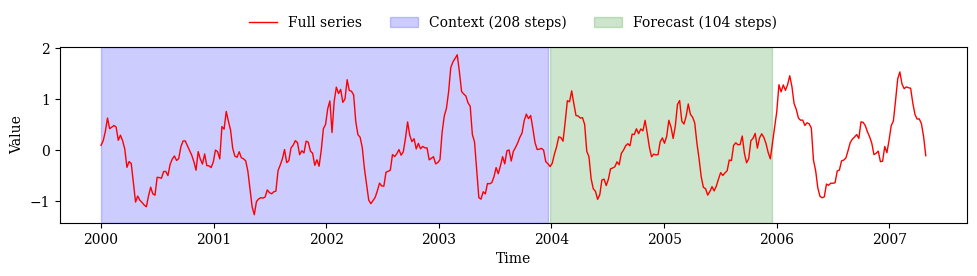

Total series length: 383
Context: indices 0-207 (208 steps)
Forecast: indices 208-311 (104 steps)


In [81]:
# Plot full data with context and forecast windows
full_timestamps = pd.date_range(
    start="2000-01-02",
    periods=len(series),
    freq="W"
)

plt.figure(figsize=(10, 3))

# Plot full series
plt.plot(full_timestamps, series, color="r", label="Full series")

# Shade context window
plt.axvspan(
    full_timestamps[0],
    full_timestamps[CONTEXT_LENGTH - 1],
    color="blue",
    alpha=0.2,
    label=f"Context ({CONTEXT_LENGTH} steps)"
)

# Shade forecast window
plt.axvspan(
    full_timestamps[CONTEXT_LENGTH],
    full_timestamps[min(CONTEXT_LENGTH + FORECAST_HORIZON - 1, len(series) - 1)],
    color="green",
    alpha=0.2,
    label=f"Forecast ({FORECAST_HORIZON} steps)"
)

plt.ylabel("Value")
plt.xlabel("Time")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    ncol=3,
    frameon=False,
)
plt.tight_layout()
plt.show()

print(f"Total series length: {len(series)}")
print(f"Context: indices 0-{CONTEXT_LENGTH-1} ({CONTEXT_LENGTH} steps)")
print(f"Forecast: indices {CONTEXT_LENGTH}-{CONTEXT_LENGTH + FORECAST_HORIZON - 1} ({FORECAST_HORIZON} steps)")

# Chronos-2

In [82]:
context_values = series[:CONTEXT_LENGTH]
true_future_values = series[CONTEXT_LENGTH : CONTEXT_LENGTH + FORECAST_HORIZON]

In [83]:
# Build context DataFrame
timestamps = pd.date_range(
    start="2000-01-02",  # arbitrary anchor
    periods=len(context_values),
    freq="W"
)

context_df = pd.DataFrame({
    "id": "Crack_data",
    "timestamp": timestamps,
    "target": context_values
})

In [84]:
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cpu")


# Run Chronos forecast
pred_df = pipeline.predict_df(
    context_df,
    prediction_length=FORECAST_HORIZON,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="target",
)

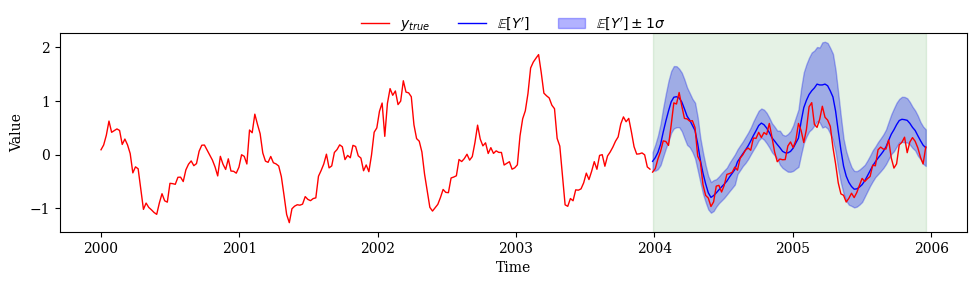

Chronos RMSE: 0.3438
Chronos Log-Likelihood: -20.4475


In [85]:
# Calculate std from quantiles first
chronos_pred = pred_df["0.5"].to_numpy()
q10 = pred_df["0.1"].to_numpy()
q90 = pred_df["0.9"].to_numpy()
chronos_std = (q90 - q10) / (2 * 1.282)

# Plot
plt.figure(figsize=(10, 3))

# Context
plt.plot(
    context_df["timestamp"],
    context_df["target"],
    label=r"$y_{true}$",
    color="r"
)

# Forecast
plt.plot(
    pred_df["timestamp"],
    chronos_pred,
    label=r"$\mathbb{E}[Y']$",
    color="blue",
)

# Use ±1σ for the uncertainty band
plt.fill_between(
    pred_df["timestamp"],
    chronos_pred - chronos_std,
    chronos_pred + chronos_std,
    color="blue",
    alpha=0.3,
    label=r"$\mathbb{E}[Y'] \pm 1\sigma$"
)

# True values (if available)
if len(true_future_values) > 0:
    plt.plot(
        pred_df["timestamp"][:len(true_future_values)],
        true_future_values,
        color="red",
    )
plt.axvspan(
    pred_df["timestamp"].iloc[0],
    pred_df["timestamp"].iloc[-1],
    color="green",
    alpha=0.1,
)
plt.ylabel("Value")
plt.xlabel("Time")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=5,
    frameon=False,
)
plt.tight_layout()
plt.show()

# Calculate metrics
rmse = metric.rmse(true_future_values, chronos_pred[:len(true_future_values)])
loglik = metric.log_likelihood(true_future_values, chronos_pred[:len(true_future_values)], chronos_std[:len(true_future_values)])

print(f"Chronos RMSE: {rmse:.4f}")
print(f"Chronos Log-Likelihood: {loglik:.4f}")

# Global TAGI-LSTM

In [86]:
# TAGI-LSTM configuration
time_covariates = ["week_of_year"]
num_features = 1 + len(time_covariates)
input_seq_len = 52
seed = 100
device = "cpu"
model_input_size = input_seq_len + num_features - 1

data = TimeSeriesDataBuilder(
    x_file=f"{DATA_PATH}/hq_train_weekly_values_shifted.csv",
    date_time_file=f"{DATA_PATH}/hq_train_weekly_dates_shifted.csv",
    input_seq_len=input_seq_len,
    output_seq_len=1,
    stride=1,
    time_covariates=time_covariates,
    scale_method="standard",
    order_mode="by_window",
    ts_to_use=[ts_idx],  # Uses the same ts_idx as Chronos
)

In [87]:
# Build model
global_stateful, output_updater = build_model(
    input_size=model_input_size,
    use_AGVI=True,
    seed=seed,
    device=device,
    init_params="/Users/davidwardan/Library/CloudStorage/OneDrive-Personal/Projects/cuTAGI_DW/out/seed11/train100/ByWindow_Obs_global_no-embeddings/param/model.bin",
    shift_biases=False,
)

In [88]:
def forecast(net, data, context_length, forecast_horizon):
    """
    Forecast with TAGI-LSTM matching the LLM-based model's setup.

    Args:
        net: The TAGI-LSTM model
        data: TimeSeriesDataBuilder object
        context_length: Number of initial time steps used as context (warm-up)
        forecast_horizon: Number of steps to forecast after context
    """
    batch_iter = BatchLoader.create_data_loader(
        dataset=data.dataset,
        order_mode="by_window",
        batch_size=1,
        shuffle=False,
        seed=1,
    )

    # Initialize look-back buffer and LSTM state container
    look_back_buffer = LookBackBuffer(input_seq_len=input_seq_len, nb_ts=1)

    net.eval()

    # Context phase storage
    context_y_true = []
    context_m_preds = []
    context_s_preds = []
    context_std_y = []

    # Forecast phase storage
    forecast_y_true = []
    forecast_m_preds = []
    forecast_s_preds = []
    forecast_std_y = []

    for (x, y), _, w_id in batch_iter:
        step = w_id[0].item()

        # Stop after context + forecast horizon
        if step >= context_length + forecast_horizon:
            break

        # Prepare look_back buffer
        if look_back_buffer.needs_initialization[0]:
            look_back_buffer.initialize(
                initial_mu=x[:, :input_seq_len],
                initial_var=np.zeros_like(x[:, :input_seq_len], dtype=np.float32),
                indices=[0],
            )

        # Prepare input
        x, var_x = prepare_input(
            x=x,
            var_x=None,
            look_back_mu=(look_back_buffer.mu),
            look_back_var=(look_back_buffer.var),
            indices=np.array([0]),
        )

        # Feedforward
        m_pred, v_pred = net(x, var_x)

        # net.reset_lstm_states()

        # Specific to AGVI
        flat_m = np.ravel(m_pred)
        flat_v = np.ravel(v_pred)

        m_pred = flat_m[::2]
        v_pred = flat_v[::2]
        var_y = flat_m[1::2]

        s_aleatoric = np.sqrt(var_y)
        s_epistemic = np.sqrt(v_pred)

        # Store results based on phase
        if step < context_length:
            # Context phase (warm-up)
            context_y_true.append(y.flatten())
            context_m_preds.append(m_pred)
            context_s_preds.append(s_epistemic)
            context_std_y.append(s_aleatoric)

            look_back_buffer.update(
                new_mu=y.flatten(),
                new_var=np.zeros_like(y.flatten(), dtype=np.float32),
                indices=[0],
            )
        else:
            # Forecast phase
            forecast_y_true.append(y.flatten())
            forecast_m_preds.append(m_pred)
            forecast_s_preds.append(s_epistemic)
            forecast_std_y.append(s_aleatoric)

            look_back_buffer.update(
                new_mu=m_pred,
                new_var=v_pred,
                indices=[0],
            )

    # Return both context and forecast results
    context_results = {
        "y_true": np.array(context_y_true),
        "m_preds": np.array(context_m_preds),
        "s_preds": np.array(context_s_preds),
        "std_y": np.array(context_std_y),
    }

    forecast_results = {
        "y_true": np.array(forecast_y_true),
        "m_preds": np.array(forecast_m_preds),
        "s_preds": np.array(forecast_s_preds),
        "std_y": np.array(forecast_std_y),
    }

    return context_results, forecast_results

In [89]:
# Align TAGI-LSTM with Chronos forecast period
tagi_context_windows = CONTEXT_LENGTH - input_seq_len

# Run forecast with aligned context/horizon
context_results, forecast_results = forecast(
    global_stateful,
    data,
    context_length=tagi_context_windows,
    forecast_horizon=FORECAST_HORIZON
)

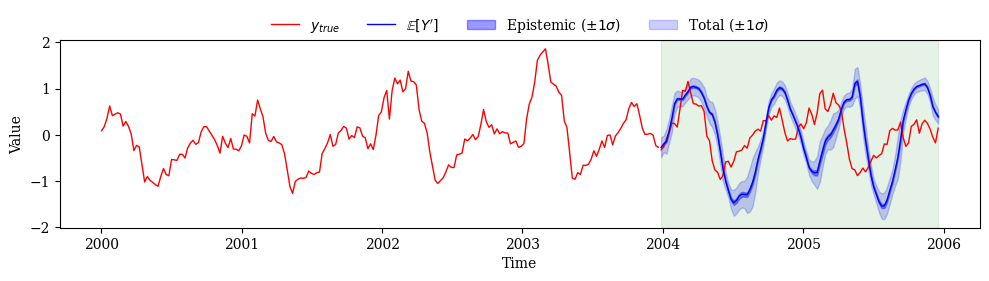

TAGI-LSTM RMSE: 0.8114
TAGI-LSTM Log-Likelihood: -687.7805


In [90]:
# Plot TAGI-LSTM results (matching Chronos period)
m_preds = forecast_results["m_preds"].flatten()
s_epistemic = forecast_results["s_preds"].flatten()
s_aleatoric = forecast_results["std_y"].flatten()
y_true_forecast = forecast_results["y_true"].flatten()

# Unstandardize results
mean = data.x_mean[0][0]
std = data.x_std[0][0]

m_preds = normalizer.unstandardize(m_preds, mean, std)
s_epistemic = normalizer.unstandardize_std(s_epistemic, std)
s_aleatoric = normalizer.unstandardize_std(s_aleatoric, std)
y_true_forecast = normalizer.unstandardize(y_true_forecast, mean, std)

# Context values for plotting (use Chronos context_df for consistency)
context_y = context_df["target"].values

# Total uncertainty: sqrt(epistemic^2 + aleatoric^2)
s_total = np.sqrt(s_epistemic**2 + s_aleatoric**2)

# Use same timestamps as Chronos for perfect alignment
context_timestamps = context_df["timestamp"]
forecast_timestamps = pred_df["timestamp"]

plt.figure(figsize=(10, 3))

# Context true values
plt.plot(context_timestamps, context_y, label=r"$y_{true}$", color="r")

# Forecast true values (continuation)
plt.plot(forecast_timestamps, y_true_forecast, color="r")

# TAGI-LSTM Forecast (mean)
plt.plot(
    forecast_timestamps,
    m_preds,
    label=r"$\mathbb{E}[Y']$",
    color="blue",
)

# Epistemic uncertainty band
plt.fill_between(
    forecast_timestamps,
    m_preds - 1 * s_epistemic,
    m_preds + 1 * s_epistemic,
    color="blue",
    alpha=0.4,
    label=r"Epistemic ($\pm 1\sigma$)",
)

# Total uncertainty band (epistemic + aleatoric)
plt.fill_between(
    forecast_timestamps,
    m_preds - 1 * s_total,
    m_preds + 1 * s_total,
    color="blue",
    alpha=0.2,
    label=r"Total ($\pm 1\sigma$)",
)

# Shade forecast region
plt.axvspan(
    forecast_timestamps.iloc[0],
    forecast_timestamps.iloc[-1],
    color="green",
    alpha=0.1,
)

plt.ylabel("Value")
plt.xlabel("Time")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.20),
    ncol=4,
    frameon=False,
)
plt.tight_layout()
plt.show()

# calculate metrics
mse = metric.rmse(m_preds, y_true_forecast)
loglik = metric.log_likelihood(m_preds, y_true_forecast, s_total)

print(f"TAGI-LSTM RMSE: {mse:.4f}")
print(f"TAGI-LSTM Log-Likelihood: {loglik:.4f}")